# Q3 Part 3 – Varying K

Solve for K = (5, 3, 2.5, 2.3, 2.1, 1.8, 1.2)$ and show phi_xs along $y=0$
on a single plot for $-1.5 < x < 1.5$.

In [194]:
import numpy as np
import matplotlib.pyplot as plt

import q3_solver
import importlib
importlib.reload(q3_solver) 

from q3_solver import (
    solve, compute_phi_x, compute_psi,
    surface_phi_x, GAMMA
)


K_values = [5.0, 3.0, 2.5, 2.3, 2.1, 1.8, 1.2]
Nx, Ny = 161, 81
q, s, r = 5.0, 5.0, 5.0
TOL = 1e-6
MAX_ITER = 80000

1. Solve for each K using continuation

In [195]:
solutions = {}
phi_prev = None

for K in K_values:
    print(f"\n{'='*40}")
    print(f"  K = {K}")
    print(f"{'='*40}")

    use_elliptic = (K >= 3.5)
    phi_init = phi_prev

    phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                      tol=TOL, max_iter=MAX_ITER, check_every=200,
                      elliptic_only=use_elliptic,
                      phi_init=phi_init, verbose=True)

    # If not converged and was elliptic-only, retry with transonic switching
    if not info["converged"] and use_elliptic:
        print("Retrying with transonic switching...")
        phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                          tol=TOL, max_iter=MAX_ITER, check_every=200,
                          elliptic_only=False,
                          phi_init=phi_prev, verbose=True)

    px = compute_phi_x(phi, info["dx"])
    psi_min = compute_psi(px, K).min()
    phi_x_peak = px[:, 0].max()
    print(f"  phi_x peak = {phi_x_peak:.6f},  psi_min = {psi_min:.4f}")
    if psi_min < 0:
        print(f"!! LOCALLY SUPERSONIC !!")

    solutions[K] = (phi, info)
    phi_prev = phi


  K = 5.0
  it      1  |res|=1.847e+01  |upd|=1.425e-02  t=0.0s
  it   2000  |res|=2.931e-02  |upd|=3.220e-05  t=14.9s
  it   4000  |res|=1.134e-02  |upd|=1.251e-05  t=30.5s
  it   6000  |res|=4.976e-03  |upd|=5.500e-06  t=45.3s
  it   8000  |res|=2.334e-03  |upd|=2.584e-06  t=59.8s
  it  10000  |res|=1.144e-03  |upd|=1.268e-06  t=74.2s
  it  12000  |res|=5.774e-04  |upd|=6.407e-07  t=88.7s
  it  14000  |res|=2.975e-04  |upd|=3.305e-07  t=103.2s
  it  16000  |res|=1.553e-04  |upd|=1.727e-07  t=117.6s
  it  18000  |res|=8.179e-05  |upd|=9.105e-08  t=132.2s
  it  20000  |res|=4.329e-05  |upd|=4.824e-08  t=146.6s
  it  22000  |res|=2.299e-05  |upd|=2.564e-08  t=161.2s
  it  24000  |res|=1.223e-05  |upd|=1.366e-08  t=175.7s
  it  26000  |res|=6.525e-06  |upd|=7.284e-09  t=190.2s
  it  28000  |res|=3.488e-06  |upd|=3.887e-09  t=204.8s
  it  30000  |res|=1.865e-06  |upd|=2.075e-09  t=219.2s
  it  32000  |res|=9.981e-07  |upd|=1.108e-09  t=233.6s
  Converged at it=32000, |res|=9.981e-07, tim

2. Combined $\phi_x$ plot on $y=0$

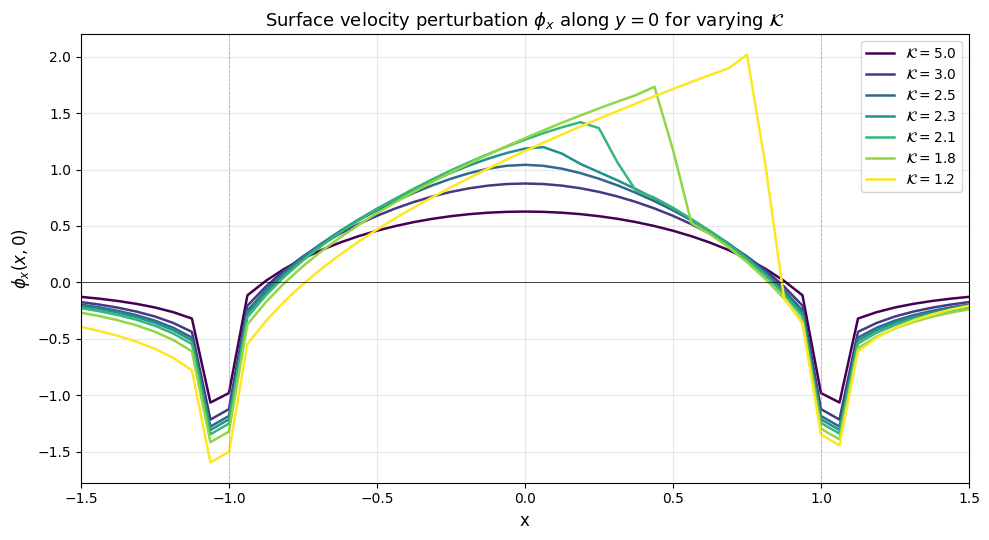

In [196]:
fig, ax = plt.subplots(figsize=(10, 5.5))

cmap = plt.cm.viridis
colors = [cmap(i / (len(K_values) - 1)) for i in range(len(K_values))]

for i, K in enumerate(K_values):
    phi, info = solutions[K]
    x = info["x"]; dx = info["dx"]
    ux = surface_phi_x(phi, dx)
    mask = (x >= -1.5) & (x <= 1.5)
    label = rf"$\mathcal{{K}} = {K}$"
    if not info["converged"]:
        label += " (not conv.)"
    ax.plot(x[mask], ux[mask], color=colors[i], lw=1.8, label=label)

ax.axhline(0, color="k", ls="-", lw=0.5)
ax.axvline(-1, color="grey", ls="--", lw=0.6, alpha=0.5)
ax.axvline( 1, color="grey", ls="--", lw=0.6, alpha=0.5)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel(r"$\phi_x(x, 0)$", fontsize=12)
ax.set_title(r"Surface velocity perturbation $\phi_x$ along $y=0$ for varying $\mathcal{K}$", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(-1.5, 1.5); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p3_phi_x_all_K.png", dpi=150, bbox_inches="tight")
plt.show()

3. Summary table

In [197]:
print(f"{'K':>5s} {'conv':>5s} {'iters':>8s} {'time(s)':>8s} "
      f"{'phi_x_peak':>12s} {'psi_min':>10s} {'type':>14s}")
print("-" * 80)
for K in K_values:
    phi, info = solutions[K]
    px = compute_phi_x(phi, info["dx"])
    psi_min = compute_psi(px, K).min()
    ux_peak = px[:, 0].max()
    ftype = "TRANSONIC" if psi_min < 0 else "SUBSONIC"
    conv_str = "Y" if info["converged"] else "N"
    print(f"{K:5.1f} {conv_str:>5s} {info['iters']:8d} {info['seconds']:8.2f} "
          f"{ux_peak:12.6f} {psi_min:10.4f} {ftype:>14s}")

print("\nSonic condition: phi_x = K / (gamma+1) = K / 2.4")
for K in K_values:
    print(f"  K={K}: sonic phi_x = {K/(GAMMA+1):.4f}")

    K  conv    iters  time(s)   phi_x_peak    psi_min           type
--------------------------------------------------------------------------------
  5.0     Y    32000   233.59     0.627693     3.4935       SUBSONIC
  3.0     Y    27000   199.51     0.876303     0.8969       SUBSONIC
  2.5     Y    26600   202.57     1.042064    -0.0010      TRANSONIC
  2.3     Y    25400   201.99     1.198595    -0.5766      TRANSONIC
  2.1     Y    27800   207.77     1.419510    -1.3068      TRANSONIC
  1.8     Y    32600   244.14     1.733373    -2.3601      TRANSONIC
  1.2     Y    41600   308.72     2.017479    -3.6419      TRANSONIC

Sonic condition: phi_x = K / (gamma+1) = K / 2.4
  K=5.0: sonic phi_x = 2.0833
  K=3.0: sonic phi_x = 1.2500
  K=2.5: sonic phi_x = 1.0417
  K=2.3: sonic phi_x = 0.9583
  K=2.1: sonic phi_x = 0.8750
  K=1.8: sonic phi_x = 0.7500
  K=1.2: sonic phi_x = 0.5000


4.Convergence history comparison

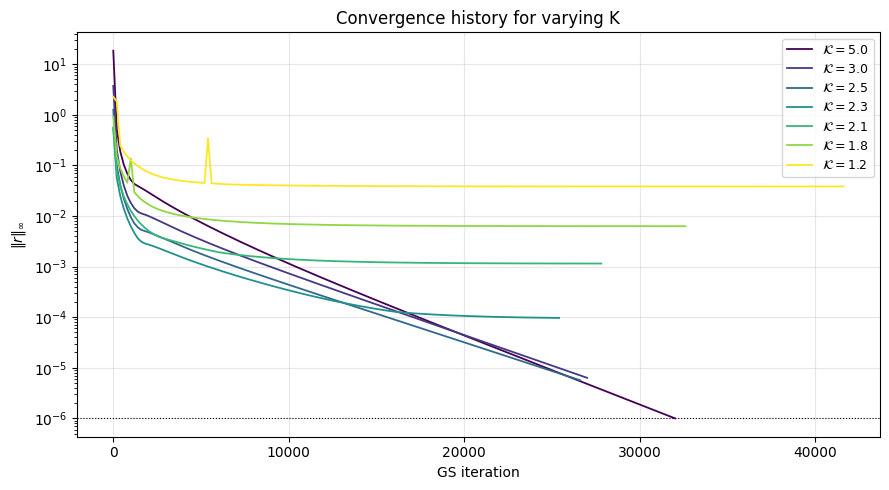

In [198]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, K in enumerate(K_values):
    _, info = solutions[K]
    hist = info["hist"]
    its = [h["it"] for h in hist]
    res = [h["res"] for h in hist]
    ax.semilogy(its, res, color=colors[i], lw=1.3,
                label=rf"$\mathcal{{K}}={K}$")

ax.axhline(TOL, color="k", ls=":", lw=0.8)
ax.set_xlabel("GS iteration"); ax.set_ylabel(r"$\|r\|_\infty$")
ax.set_title("Convergence history for varying K")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p3_convergence_all_K.png", dpi=150, bbox_inches="tight")
plt.show()

## Discussion

As $\mathcal{K}$ decreases:
1. The peak $\phi_x$ on the bump surface increases — the flow accelerates more.
2. When $\phi_x$ reaches $\mathcal{K}/(\gamma+1)$ the local Mach number reaches unity
   and $\psi = 0$ (sonic line appears).
3. For smaller $\mathcal{K}$, a supersonic pocket forms above the bump, terminated by a shock
   (discontinuity in $\phi_x$) — requiring the upwind (backward) difference for stability.
4. Convergence becomes progressively harder as $\mathcal{K}$ decreases due to the mixed
   elliptic-hyperbolic nature of the PDE.
5. Parameter continuation (warm-starting from higher $\mathcal{K}$) is essential for
   the lowest $\mathcal{K}$ values to achieve convergence.